# 03. Repo 메타데이터 수집 & 해석

repo_id만으로는 어떤 프로젝트인지 알 수 없습니다.

GitHub REST API를 활용해 메타데이터(language, stars, topics 등)를 수집하고,  
예측 결과를 **해석 가능한 형태**로 만듭니다.

## 1. Top Repo의 이름 매핑 (BigQuery)

In [ ]:
import os
from datetime import date
from pathlib import Path

from gharchive.client import create_client
from ghrec.recommend import load_period, popularity_scores, top_n_repos

OUTPUT_DIR = Path("../../data/daily_agg")
KEY_PATH = os.environ.get("GCP_KEY_PATH", "gcp-key.json")

# 전체 기간 로드 (메타데이터 수집 대상 = 전체 Top repo)
df = load_period(OUTPUT_DIR, date(2026, 2, 15), date(2026, 3, 14))

WEIGHTS = {
    "WatchEvent": 1.0,
    "ForkEvent": 2.0,
    "IssuesEvent": 0.5,
    "PullRequestEvent": 3.0,
    "IssueCommentEvent": 0.3,
    "PushEvent": 0.2,
}

scores = popularity_scores(df, WEIGHTS)
top_ids = top_n_repos(scores, 100).index.tolist()
print(f"메타데이터 수집 대상: Top {len(top_ids)} repos")

In [18]:
# BigQuery에서 repo_id → repo_name 매핑
client = create_client(KEY_PATH)

ids_str = ", ".join(str(rid) for rid in top_ids)
name_query = f"""
SELECT DISTINCT repo.id AS repo_id, repo.name AS repo_name
FROM `githubarchive.day.20260314`
WHERE repo.id IN ({ids_str})
"""

repo_names_df = client.query(name_query).to_dataframe()
repo_name_map = dict(zip(repo_names_df["repo_id"], repo_names_df["repo_name"]))
print(f"Resolved {len(repo_name_map)}/{len(top_ids)} repo names")
repo_names_df.head(10)

Resolved 91/100 repo names


,repo_id,repo_name
0,1174820787,karpathy/autoresearch
1,678894831,leandrohstein/transporteservico-urbs-data
2,1092687660,marcusquinn/aidevops
3,1159670668,Spikewmu/n8n-workflow-backups2026
4,1076470140,gaston1799/RobloxLua
5,1013904109,0xlegionz/myPRoject
6,1015761727,anton2423/didactic-broccoli
7,1164751568,BorjaGM1/meaningfull-commits
8,1038068383,xiaoandy1974g/gdl
9,1081821939,neco222/RSS


## 2. GitHub REST API 소개

GitHub REST API는 repo의 상세 정보를 제공합니다.

```
GET https://api.github.com/repos/{owner}/{repo}
```

응답에는 language, stargazers_count, forks_count, topics, license 등이 포함됩니다.

- **Rate limit**: 인증 없이 60회/시간, 토큰 있으면 5,000회/시간
- 토큰은 [github.com/settings/tokens](https://github.com/settings/tokens)에서 생성

In [19]:
# 단일 호출 데모
from ghrec.metadata import fetch_repo_metadata

sample_name = list(repo_name_map.values())[0]
print(f"Fetching metadata for: {sample_name}")
meta = fetch_repo_metadata(sample_name)

for key, val in meta.items():
    print(f"  {key}: {val}")

Fetching metadata for: karpathy/autoresearch
  http_status: 403


## 3. SQLite 캐시 배치 구축

GitHub API를 호출할 때마다 SQLite에 캐싱합니다.  
한 번 수집한 repo는 다시 호출하지 않습니다.

> **참고**: 토큰 없이 실행하면 rate limit 때문에 느릴 수 있습니다.  
> `GITHUB_TOKEN` 환경변수를 설정하면 5,000회/시간으로 늘어납니다.

In [20]:
import subprocess

from ghrec.metadata import fetch_and_cache_repos, get_metadata_df, init_db

DB_PATH = Path("../../data/repo_metadata.db")

# gh CLI에서 토큰 가져오기
GITHUB_TOKEN = subprocess.run(
    ["gh", "auth", "token"], capture_output=True, text=True
).stdout.strip() or None
print(f"Token: {'set' if GITHUB_TOKEN else 'not set'}")

conn = init_db(DB_PATH)

# repo_name_map: {repo_id: "owner/repo"}
# 토큰 있으면 5,000회/시간이라 pause 짧게 가능
meta_df = fetch_and_cache_repos(
    conn, repo_name_map, token=GITHUB_TOKEN,
    rate_limit_pause=0.3 if GITHUB_TOKEN else 0.8,
)

print(f"Total cached repos: {len(meta_df)}")
meta_df.head()

Token: set
Total cached repos: 91


,repo_id,repo_name,description,language,stargazers,forks,topics,license_key,created_at,updated_at,archived,fetched_at,http_status
0,724712,rust-lang/rust,Empowering everyone to build reliable and effi...,Rust,111206,14621,"[""compiler"", ""language"", ""rust""]",Apache-2.0,2010-06-16T20:39:03Z,2026-03-15T06:47:00Z,0,2026-03-15T07:36:46.307973+00:00,200
1,3623050,Homebrew/homebrew-cask,🍻 A CLI workflow for the administration of mac...,Ruby,21892,11371,"[""cask"", ""hacktoberfest"", ""homebrew""]",BSD-2-Clause,2012-03-05T02:05:17Z,2026-03-15T07:13:19Z,0,2026-03-15T07:38:01.082342+00:00,200
2,4542716,NixOS/nixpkgs,Nix Packages collection & NixOS,Nix,23862,18315,"[""hacktoberfest"", ""linux"", ""nix"", ""nixos"", ""ni...",MIT,2012-06-04T02:49:46Z,2026-03-15T07:35:45Z,0,2026-03-15T07:37:58.660840+00:00,200
3,7833168,elastic/kibana,Your window into all of your data,TypeScript,21000,8542,"[""dashboards"", ""elasticsearch"", ""hacktoberfest...",NOASSERTION,2013-01-26T04:00:59Z,2026-03-14T22:34:58Z,0,2026-03-15T07:37:08.225724+00:00,200
4,12888993,home-assistant/core,:house_with_garden: Open source home automatio...,Python,85347,36991,"[""asyncio"", ""hacktoberfest"", ""home-automation""...",Apache-2.0,2013-09-17T07:29:48Z,2026-03-15T07:19:55Z,0,2026-03-15T07:36:48.929727+00:00,200


## 4. 메타데이터 탐색

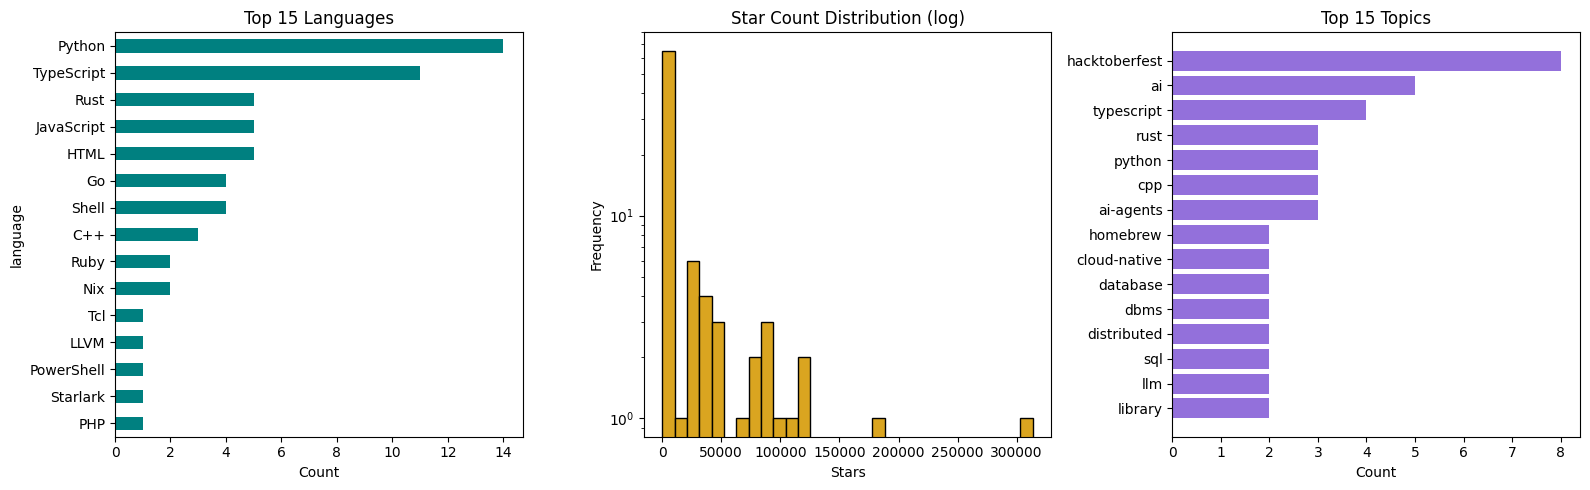

In [21]:
import json

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4-1. Language 분포
success_df = meta_df[meta_df["http_status"] == 200].copy()
lang_counts = success_df["language"].value_counts().head(15)
lang_counts.plot.barh(ax=axes[0], color="teal")
axes[0].set_title("Top 15 Languages")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# 4-2. Star 분포 (log scale)
success_df["stargazers"].clip(lower=1).plot.hist(
    ax=axes[1], bins=30, log=True, color="goldenrod", edgecolor="black"
)
axes[1].set_title("Star Count Distribution (log)")
axes[1].set_xlabel("Stars")

# 4-3. Topic 빈도
all_topics = []
for t in success_df["topics"].dropna():
    all_topics.extend(json.loads(t))
from collections import Counter
topic_counts = Counter(all_topics).most_common(15)
if topic_counts:
    names, counts = zip(*topic_counts)
    axes[2].barh(names, counts, color="mediumpurple")
    axes[2].set_title("Top 15 Topics")
    axes[2].set_xlabel("Count")
    axes[2].invert_yaxis()
else:
    axes[2].set_title("No topics found")

plt.tight_layout()
plt.show()

## 5. 예측 결과 해석

03번 노트북에서 만든 predicted Top-N에 메타데이터를 join해서 "어떤 repo가 추천되었는지" 해석합니다.

In [22]:
# Train 기간 인기도 기반 Top-30 예측
TRAIN_START, TRAIN_END = date(2026, 2, 15), date(2026, 3, 7)
train_df = load_period(OUTPUT_DIR, TRAIN_START, TRAIN_END)
train_scores = popularity_scores(train_df, WEIGHTS)
predicted_ids = top_n_repos(train_scores, 30).index.tolist()

# 예측 결과에 메타데이터 join
predicted_meta = get_metadata_df(conn, predicted_ids)
predicted_meta = predicted_meta.set_index("repo_id").loc[
    [rid for rid in predicted_ids if rid in predicted_meta["repo_id"].values]
]

# 보기 좋게 정리
display_cols = ["repo_name", "language", "stargazers", "forks", "license_key", "description"]
available_cols = [c for c in display_cols if c in predicted_meta.columns]
predicted_meta["rank"] = range(1, len(predicted_meta) + 1)

print("Predicted Top-30 with metadata:")
print(predicted_meta[["rank"] + available_cols].to_string(max_colwidth=60))

Predicted Top-30 with metadata:
            rank                                  repo_name    language  stargazers  forks   license_key                                                  description
repo_id                                                                                                                                                              
1103012935     1                          openclaw/openclaw  TypeScript      313673  59853           MIT  Your own personal AI assistant. Any OS. Any Platform. Th...
678894831      2  leandrohstein/transporteservico-urbs-data         NaN           0      1       GPL-3.0  Repositório para armazenamento de exemplos de JSON do se...
4542716        3                              NixOS/nixpkgs         Nix       23862  18315           MIT                              Nix Packages collection & NixOS
1156956890     4                     zeroclaw-labs/zeroclaw        Rust       27101   3583    Apache-2.0  Fast, small, and fully autonomou

In [23]:
# 추천된 repo들의 language 분포
pred_lang = predicted_meta["language"].value_counts()
print("추천 Top-30의 언어 분포:")
print(pred_lang.to_string())
print(f"\n고유 언어 수: {len(pred_lang)}")

추천 Top-30의 언어 분포:
language
Python        6
TypeScript    4
HTML          2
Nix           1
Rust          1
PowerShell    1
Lua           1
JavaScript    1
Ruby          1

고유 언어 수: 9


## 6. 정리 & 다음 단계

**이번 노트북에서 한 것:**
- BigQuery로 repo_id → repo_name 매핑
- GitHub REST API로 메타데이터 수집 (language, stars, topics, license 등)
- SQLite 캐시로 반복 호출 방지
- 예측 결과(Top-N)에 메타데이터를 붙여서 해석

**다음 단계:**
- 메타데이터를 **feature로** 활용하는 ML 모델 구축
- 유저별 과거 이벤트 + repo 속성 → 개인화 추천

In [24]:
conn.close()